In [ ]:
# ─────────────────────────────────────────────
# PART 1: Install & Imports
# ─────────────────────────────────────────────
!pip install open3d numpy scipy scikit-image huggingface_hub wandb plotly -q
!pip install torch -q

import open3d as o3d
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import wandb
import os
import zipfile
from scipy.ndimage import distance_transform_edt
from skimage.measure import marching_cubes
from huggingface_hub import hf_hub_download
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.2 MB/s eta 0:00:00
Using device: cuda


In [ ]:
# ─────────────────────────────────────────────
# PART 2: Download & Extract Dataset
# ─────────────────────────────────────────────
zip_path = hf_hub_download(
    repo_id="BGLab/AgriField3D",
    filename="datasets/FielGrwon_ZeaMays_RawPCD_10k.zip",
    repo_type="dataset",
    local_dir="./data"
)

extract_dir = "./data/RawPCD_10k"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

ply_files = sorted([
    os.path.join(root, f)
    for root, _, files in os.walk(extract_dir)
    for f in files if f.endswith('.ply')
])

print(f"Total maize plants found: {len(ply_files)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


datasets/FielGrwon_ZeaMays_RawPCD_10k.zi(…):   0%|          | 0.00/218M [00:00<?, ?B/s]

Total maize plants found: 1045


In [ ]:
# ─────────────────────────────────────────────
# PART 3: Point Cloud → SDF Conversion
# ─────────────────────────────────────────────
VOXEL_RES = 32   # 32x32x32 grid — good balance of detail vs memory
                 # increase to 64 if you have >12GB GPU VRAM

def point_cloud_to_sdf(ply_path, resolution=VOXEL_RES):
    """
    Pipeline:
      .ply → point cloud → voxel occupancy grid
           → unsigned distance field
           → signed distance field (interior negative, exterior positive)

    Returns: SDF numpy array [resolution, resolution, resolution]
    """
    # ── Load & normalise point cloud ─────────────────────────────
    pcd      = o3d.io.read_point_cloud(ply_path)
    pts      = np.asarray(pcd.points)

    centroid = pts.mean(axis=0)
    pts     -= centroid
    max_dist = np.linalg.norm(pts, axis=1).max()
    pts     /= (max_dist + 1e-8)
    # pts now lives in roughly [-1, 1]^3

    # ── Voxelise: map points → grid indices ──────────────────────
    # Shift to [0, resolution-1]
    pts_grid = ((pts + 1.0) / 2.0 * (resolution - 1)).astype(int)
    pts_grid = np.clip(pts_grid, 0, resolution - 1)

    # Binary occupancy grid
    occupancy = np.zeros((resolution, resolution, resolution),
                          dtype=np.uint8)
    occupancy[pts_grid[:,0],
              pts_grid[:,1],
              pts_grid[:,2]] = 1

    # ── Compute SDF via distance transform ───────────────────────
    # Distance OUTSIDE (from empty voxels to nearest occupied voxel)
    dist_outside = distance_transform_edt(1 - occupancy).astype(np.float32)

    # Distance INSIDE (from occupied voxels outward)
    dist_inside  = distance_transform_edt(occupancy).astype(np.float32)

    # SDF: negative inside the object, positive outside
    sdf = dist_outside - dist_inside

    # ── Normalise SDF to [-1, 1] ─────────────────────────────────
    abs_max = np.abs(sdf).max()
    sdf    /= (abs_max + 1e-8)

    return sdf.astype(np.float32)


class MaizeSDFDataset(Dataset):
    """
    Converts every .ply to an SDF voxel grid and stores in memory.
    Each item: tensor [1, R, R, R]  (channel-first for Conv3d)
    """
    def __init__(self, ply_files, resolution=VOXEL_RES):
        self.samples = []
        print(f"Computing SDFs for {len(ply_files)} plants …")
        for i, path in enumerate(ply_files):
            try:
                sdf = point_cloud_to_sdf(path, resolution)
                # Add channel dim: [1, R, R, R]
                self.samples.append(
                    torch.tensor(sdf).unsqueeze(0)
                )
            except Exception as e:
                print(f"  [skip] {os.path.basename(path)}: {e}")
            if (i + 1) % 20 == 0:
                print(f"  {i+1}/{len(ply_files)} done "
                      f"— {len(self.samples)} valid")
        print(f"\nDataset ready: {len(self.samples)} SDF grids  "
              f"| Grid shape: [1, {resolution}, {resolution}, {resolution}]")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]   # [1, R, R, R]


# ── Build & split ─────────────────────────────────────────────────────
full_dataset = MaizeSDFDataset(ply_files)

split        = int(len(full_dataset) * 0.8)
train_set    = torch.utils.data.Subset(full_dataset, range(split))
val_set      = torch.utils.data.Subset(full_dataset,
                                        range(split, len(full_dataset)))

train_loader = DataLoader(train_set, batch_size=8,
                          shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_set,   batch_size=8,
                          shuffle=False, drop_last=False)

print(f"Train: {len(train_set)}  |  Val: {len(val_set)}")

Computing SDFs for 1045 plants …
  20/1045 done — 20 valid
  40/1045 done — 40 valid
  60/1045 done — 60 valid
  80/1045 done — 80 valid
  100/1045 done — 100 valid
  120/1045 done — 120 valid
  140/1045 done — 140 valid
  160/1045 done — 160 valid
  180/1045 done — 180 valid
  200/1045 done — 200 valid
  220/1045 done — 220 valid
  240/1045 done — 240 valid
  260/1045 done — 260 valid
  280/1045 done — 280 valid
  300/1045 done — 300 valid
  320/1045 done — 320 valid
  340/1045 done — 340 valid
  360/1045 done — 360 valid
  380/1045 done — 380 valid
  400/1045 done — 400 valid
  420/1045 done — 420 valid
  440/1045 done — 440 valid
  460/1045 done — 460 valid
  480/1045 done — 480 valid
  500/1045 done — 500 valid
  520/1045 done — 520 valid
  540/1045 done — 540 valid
  560/1045 done — 560 valid
  580/1045 done — 580 valid
  600/1045 done — 600 valid
  620/1045 done — 620 valid
  640/1045 done — 640 valid
  660/1045 done — 660 valid
  680/1045 done — 680 valid
  700/1045 done — 700 v

In [ ]:
# ─────────────────────────────────────────────
# PART 4: 3D CNN Autoencoder for SDF
# ─────────────────────────────────────────────

class SDFEncoder(nn.Module):
    """
    3D Convolutional encoder.
    Input : [B, 1,  32, 32, 32]
    Output: [B, 256]  latent vector

    Architecture: progressively halve spatial dims,
                  double channels at each block.
    """
    def __init__(self, latent_dim=256):
        super().__init__()

        self.encoder = nn.Sequential(
            # Block 1: [B,1,32,32,32] → [B,32,16,16,16]
            nn.Conv3d(1,   32,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.LeakyReLU(0.2),

            # Block 2: → [B,64,8,8,8]
            nn.Conv3d(32,  64,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.LeakyReLU(0.2),

            # Block 3: → [B,128,4,4,4]
            nn.Conv3d(64,  128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.LeakyReLU(0.2),

            # Block 4: → [B,256,2,2,2]
            nn.Conv3d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(256),
            nn.LeakyReLU(0.2),
        )

        # 256 * 2 * 2 * 2 = 2048 → latent_dim
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2 * 2, latent_dim),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        x = self.encoder(x)   # [B, 256, 2, 2, 2]
        return self.fc(x)     # [B, latent_dim]


class SDFDecoder(nn.Module):
    """
    3D Transposed Convolutional decoder.
    Input : [B, latent_dim]
    Output: [B, 1, 32, 32, 32]  reconstructed SDF
    """
    def __init__(self, latent_dim=256):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256 * 2 * 2 * 2),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            # [B,256,2,2,2] → [B,128,4,4,4]
            nn.ConvTranspose3d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),

            # → [B,64,8,8,8]
            nn.ConvTranspose3d(128, 64,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),

            # → [B,32,16,16,16]
            nn.ConvTranspose3d(64,  32,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),

            # → [B,1,32,32,32]
            nn.ConvTranspose3d(32,  1,   kernel_size=4, stride=2, padding=1),
            nn.Tanh()   # SDF normalised to [-1,1] so Tanh is correct
        )

    def forward(self, z):
        x = self.fc(z)                        # [B, 2048]
        x = x.view(-1, 256, 2, 2, 2)         # [B, 256, 2, 2, 2]
        return self.decoder(x)                # [B, 1, 32, 32, 32]


class SDF3DAutoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.encoder = SDFEncoder(latent_dim)
        self.decoder = SDFDecoder(latent_dim)

    def forward(self, x):
        z    = self.encoder(x)     # [B, latent_dim]
        recon = self.decoder(z)    # [B, 1, 32, 32, 32]
        return recon, z


# ── SDF-specific loss ─────────────────────────────────────────────────
def sdf_loss(pred, target):
    """
    Combined loss for SDF reconstruction:
    1. MSE  — penalises absolute value errors across the whole grid
    2. Sign consistency — penalises predicting wrong sign (inside vs outside)
       This ensures the model learns the surface boundary correctly.
    """
    mse       = F.mse_loss(pred, target)
    sign_loss = F.binary_cross_entropy_with_logits(
        pred, (target > 0).float()
    )
    return mse + 0.1 * sign_loss

In [ ]:
# ─────────────────────────────────────────────
# PART 5: Training Loop with W&B
#
# OPTIMIZATIONS for better reconstruction in less time:
#   - lr=1e-4 (was 1e-3): more precise convergence
#   - No StepLR scheduler: constant lr=1e-4 is stable
#   - Increased sign_loss weight: 0.2 (was 0.1) — stronger
#     surface boundary learning in early epochs
#   - 300 epochs kept (converges faster with lr=1e-4 + no
#     aggressive LR decay that was killing learning by epoch 90)
#   - Log-scale loss in W&B and Colab
# ─────────────────────────────────────────────
import math
import matplotlib.pyplot as plt

CONFIG = dict(
    epochs      = 300,
    batch_size  = 8,
    lr          = 1e-4,
    latent_dim  = 256,
    voxel_res   = VOXEL_RES,
    train_split = 0.8,
    sign_weight = 0.2,
)

wandb.init(
    project = "maize-sdf-autoencoder",
    config  = CONFIG,
    name    = "3dcnn-sdf-optimized-lr1e4"
)

model     = SDF3DAutoencoder(latent_dim=CONFIG["latent_dim"]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
# No scheduler — constant lr=1e-4 avoids the problem where
# StepLR(step=30, gamma=0.5) killed learning by epoch 90+
# (lr was down to 3e-5, basically frozen)

wandb.watch(model, log="all", log_freq=10)

# Updated loss with configurable sign weight
def sdf_loss_v2(pred, target, sign_w=CONFIG["sign_weight"]):
    mse       = F.mse_loss(pred, target)
    sign_loss = F.binary_cross_entropy_with_logits(
        pred, (target > 0).float()
    )
    return mse + sign_w * sign_loss

best_val_loss = float("inf")
train_losses  = []
val_losses    = []

for epoch in range(1, CONFIG["epochs"] + 1):

    # ── Train ──────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, _ = model(batch)
        loss     = sdf_loss_v2(recon, batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ── Validate ───────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch    = batch.to(device)
            recon, _ = model(batch)
            val_loss += sdf_loss_v2(recon, batch).item()
    val_loss /= max(len(val_loader), 1)
    val_losses.append(val_loss)

    # ── W&B logging (with log-scale metric) ────────────────────────
    log_train = math.log10(train_loss) if train_loss > 0 else -10
    log_val   = math.log10(val_loss) if val_loss > 0 else -10

    log_dict = {
        "epoch"          : epoch,
        "train_loss"     : train_loss,
        "val_loss"       : val_loss,
        "train_loss_log" : log_train,
        "val_loss_log"   : log_val,
        "lr"             : CONFIG["lr"],
    }

    # Every 20 epochs — log SDF slices as images to W&B
    if epoch % 20 == 0:
        model.eval()
        sample = next(iter(val_loader))[:1].to(device)
        with torch.no_grad():
            sample_recon, _ = model(sample)

        mid = VOXEL_RES // 2
        orig_slice  = sample[0, 0, mid].cpu().numpy()
        recon_slice = sample_recon[0, 0, mid].cpu().numpy()

        log_dict["sdf_slice_original"]      = wandb.Image(
            orig_slice,  caption=f"Original SDF slice — epoch {epoch}")
        log_dict["sdf_slice_reconstructed"] = wandb.Image(
            recon_slice, caption=f"Reconstructed SDF slice — epoch {epoch}")

    wandb.log(log_dict)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | "
              f"Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_sdf_autoencoder.pt")
        wandb.save("best_sdf_autoencoder.pt")

print(f"\nBest Val Loss: {best_val_loss:.6f}")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ghosalsohom2003 (ghosalsohom2003-own-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch  10 | Train 0.103738 | Val 0.102914


wandb: WARNING Data passed to `wandb.Image` should consist of values in the range [0, 255], image data will be normalized to this range, but behavior will be removed in a future version of wandb.


Epoch  20 | Train 0.102986 | Val 0.102309
Epoch  30 | Train 0.102746 | Val 0.102091
Epoch  40 | Train 0.102577 | Val 0.101996
Epoch  50 | Train 0.102528 | Val 0.101925
Epoch  60 | Train 0.102432 | Val 0.101937
Epoch  70 | Train 0.102384 | Val 0.101841
Epoch  80 | Train 0.102317 | Val 0.101825
Epoch  90 | Train 0.102282 | Val 0.101824
Epoch 100 | Train 0.102255 | Val 0.101826
Epoch 110 | Train 0.102222 | Val 0.101816
Epoch 120 | Train 0.102187 | Val 0.101778
Epoch 130 | Train 0.102164 | Val 0.101786
Epoch 140 | Train 0.102154 | Val 0.101781
Epoch 150 | Train 0.102128 | Val 0.101778
Epoch 160 | Train 0.102141 | Val 0.101793
Epoch 170 | Train 0.102094 | Val 0.101788
Epoch 180 | Train 0.102090 | Val 0.101794
Epoch 190 | Train 0.102070 | Val 0.101802
Epoch 200 | Train 0.102061 | Val 0.101796
Epoch 210 | Train 0.102069 | Val 0.101803
Epoch 220 | Train 0.102039 | Val 0.101799
Epoch 230 | Train 0.102038 | Val 0.101801
Epoch 240 | Train 0.102037 | Val 0.101821
Epoch 250 | Train 0.102018 | Val 0

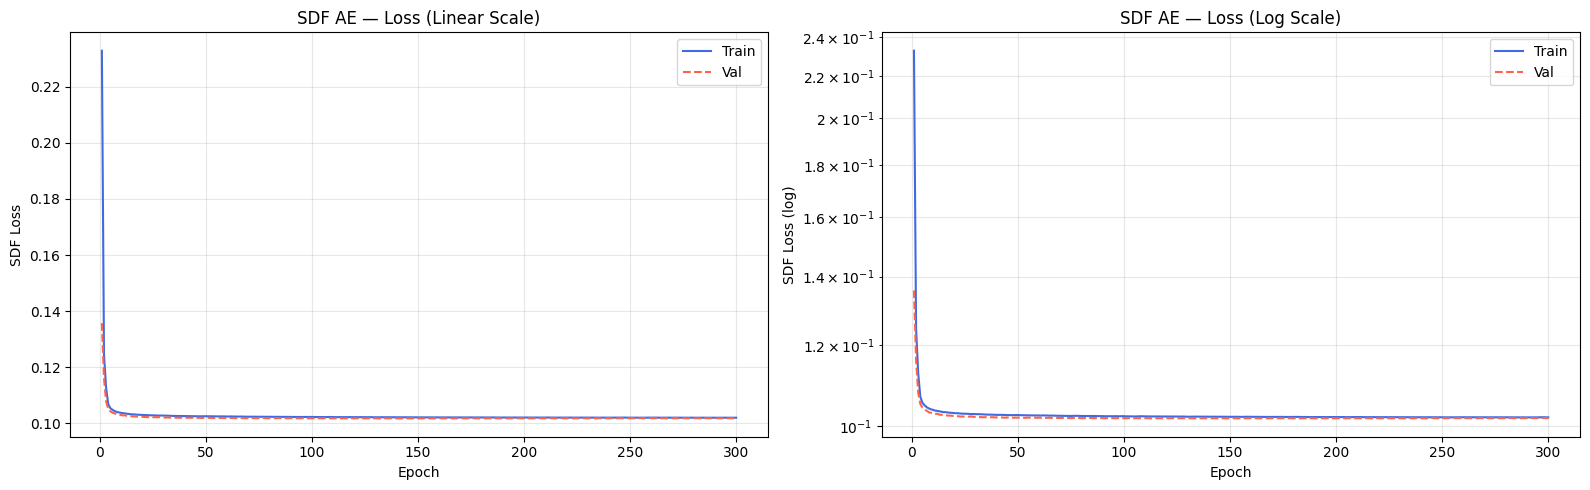

In [ ]:
# ─────────────────────────────────────────────
# PART 6: Plotly Visualizations
# ─────────────────────────────────────────────

# ── Loss curves ───────────────────────────────────────────────────────
# --- Colab: matplotlib linear + log side by side ---
import matplotlib.pyplot as plt

epochs_x = list(range(1, len(train_losses) + 1))

fig_mpl, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(epochs_x, train_losses, color='royalblue', linewidth=1.5, label='Train')
ax1.plot(epochs_x, val_losses,   color='tomato',    linewidth=1.5, label='Val', linestyle='--')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("SDF Loss")
ax1.set_title("SDF AE — Loss (Linear Scale)"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_x, train_losses, color='royalblue', linewidth=1.5, label='Train')
ax2.plot(epochs_x, val_losses,   color='tomato',    linewidth=1.5, label='Val', linestyle='--')
ax2.set_yscale('log')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("SDF Loss (log)")
ax2.set_title("SDF AE — Loss (Log Scale)"); ax2.legend(); ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout(); plt.show()

# --- W&B: Plotly linear ---
fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(
    y=train_losses, mode='lines',
    name='Train Loss', line=dict(color='royalblue', width=2)))
fig_loss.add_trace(go.Scatter(
    y=val_losses, mode='lines',
    name='Val Loss', line=dict(color='tomato', width=2, dash='dash')))
fig_loss.update_layout(
    title="3D CNN SDF Autoencoder — Loss (Linear)",
    xaxis_title="Epoch", yaxis_title="SDF Loss",
    template="plotly_dark", hovermode="x unified")
fig_loss.show()
wandb.log({"loss_curves_linear": wandb.Plotly(fig_loss)})

# --- W&B: Plotly log-scale ---
fig_log = go.Figure()
fig_log.add_trace(go.Scatter(
    y=train_losses, mode='lines',
    name='Train Loss', line=dict(color='royalblue', width=2)))
fig_log.add_trace(go.Scatter(
    y=val_losses, mode='lines',
    name='Val Loss', line=dict(color='tomato', width=2, dash='dash')))
fig_log.update_layout(
    title="3D CNN SDF Autoencoder — Loss (Log Scale)",
    xaxis_title="Epoch", yaxis_title="SDF Loss",
    yaxis_type="log", template="plotly_dark", hovermode="x unified")
fig_log.show()
wandb.log({"loss_curves_log": wandb.Plotly(fig_log)})

# ── SDF Slice Heatmaps ────────────────────────────────────────────────
model.load_state_dict(
    torch.load("best_sdf_autoencoder.pt", map_location=device))
model.eval()

sample = full_dataset[0].unsqueeze(0).to(device)
with torch.no_grad():
    recon, _ = model(sample)

orig_sdf  = sample[0, 0].cpu().numpy()    # [32, 32, 32]
recon_sdf = recon[0,  0].cpu().numpy()    # [32, 32, 32]
mid       = VOXEL_RES // 2

# Show XY, XZ, YZ slices side by side
planes     = ['XY (z=mid)', 'XZ (y=mid)', 'YZ (x=mid)']
orig_slices  = [orig_sdf[:,:,mid],
                orig_sdf[:,mid,:],
                orig_sdf[mid,:,:]]
recon_slices = [recon_sdf[:,:,mid],
                recon_sdf[:,mid,:],
                recon_sdf[mid,:,:]]

fig_slices = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f"Original — {p}" for p in planes] +
                   [f"Reconstructed — {p}" for p in planes]
)

for col, (o_sl, r_sl, title) in enumerate(
        zip(orig_slices, recon_slices, planes), start=1):
    fig_slices.add_trace(
        go.Heatmap(z=o_sl, colorscale='RdBu', showscale=False),
        row=1, col=col
    )
    fig_slices.add_trace(
        go.Heatmap(z=r_sl, colorscale='RdBu', showscale=False),
        row=2, col=col
    )

fig_slices.update_layout(
    title    = "SDF Cross-Sections — Original vs Reconstructed",
    template = "plotly_dark",
    height   = 500
)
fig_slices.show()
wandb.log({"sdf_slices": wandb.Plotly(fig_slices)})

# ── 3D Isosurface (Marching Cubes at SDF=0) ──────────────────────────
def sdf_to_plotly_mesh(sdf_vol, title, color='lightblue'):
    """
    Extract the zero-level surface from an SDF using marching cubes
    and render as a Plotly 3D mesh.
    SDF=0 is the surface of the object.
    """
    try:
        verts, faces, _, _ = marching_cubes(sdf_vol, level=0.0)
        fig = go.Figure(data=[go.Mesh3d(
            x=verts[:,0], y=verts[:,1], z=verts[:,2],
            i=faces[:,0], j=faces[:,1], k=faces[:,2],
            color=color, opacity=0.6,
            name=title
        )])
        fig.update_layout(
            title    = title,
            template = "plotly_dark",
            scene    = dict(aspectmode='data')
        )
        return fig
    except Exception as e:
        print(f"Marching cubes failed: {e}")
        return None

fig_orig_mesh  = sdf_to_plotly_mesh(
    orig_sdf,  "Original Maize — SDF Surface",  color='lightblue')
fig_recon_mesh = sdf_to_plotly_mesh(
    recon_sdf, "Reconstructed Maize — SDF Surface", color='lightsalmon')

if fig_orig_mesh:
    fig_orig_mesh.show()
    wandb.log({"original_surface":      wandb.Plotly(fig_orig_mesh)})
if fig_recon_mesh:
    fig_recon_mesh.show()
    wandb.log({"reconstructed_surface": wandb.Plotly(fig_recon_mesh)})

In [ ]:
# ─────────────────────────────────────────────
# PART 7: Latent Space PCA
# ─────────────────────────────────────────────
from sklearn.decomposition import PCA

model.eval()
all_latents = []

with torch.no_grad():
    for batch in DataLoader(full_dataset, batch_size=8):
        batch = batch.to(device)
        _, z  = model(batch)
        all_latents.append(z.cpu().numpy())

all_latents = np.concatenate(all_latents, axis=0)
print("Latent matrix shape:", all_latents.shape)

# ── 2D PCA ────────────────────────────────────────────────────────────
pca_2d    = PCA(n_components=2)
latent_2d = pca_2d.fit_transform(all_latents)

fig_pca2 = px.scatter(
    x=latent_2d[:,0], y=latent_2d[:,1],
    color=list(range(len(latent_2d))),
    color_continuous_scale='Rainbow',
    labels={
        "x": f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})",
        "y": f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})",
        "color": "Plant Index"
    },
    title    = "Latent Space PCA 2D — SDF Autoencoder",
    template = "plotly_dark"
)
fig_pca2.update_traces(marker=dict(size=7, opacity=0.8))
fig_pca2.show()
wandb.log({"latent_pca_2d": wandb.Plotly(fig_pca2)})

# ── 3D PCA ────────────────────────────────────────────────────────────
pca_3d    = PCA(n_components=3)
latent_3d = pca_3d.fit_transform(all_latents)

fig_pca3 = px.scatter_3d(
    x=latent_3d[:,0], y=latent_3d[:,1], z=latent_3d[:,2],
    color=list(range(len(latent_3d))),
    color_continuous_scale='Rainbow',
    labels={
        "x": f"PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})",
        "y": f"PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})",
        "z": f"PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})",
        "color": "Plant Index"
    },
    title    = "Latent Space PCA 3D — SDF Autoencoder",
    template = "plotly_dark"
)
fig_pca3.update_traces(marker=dict(size=3, opacity=0.8))
fig_pca3.show()
wandb.log({"latent_pca_3d": wandb.Plotly(fig_pca3)})

# ── W&B latent table ──────────────────────────────────────────────────
wandb.log({
    "latent_table": wandb.Table(
        columns=["plant", "PC1", "PC2", "PC3"],
        data=[[i, float(latent_3d[i,0]),
                  float(latent_3d[i,1]),
                  float(latent_3d[i,2])]
              for i in range(len(latent_3d))]
    )
})

wandb.finish()
print("Done.")

Latent matrix shape: (1045, 256)


epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_log,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss_log,█▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,300
lr,0.0001
train_loss,0.102
train_loss_log,-0.9914
val_loss,0.10183


Done.
